In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!cp -r /content/drive/MyDrive/DL_Project/datasets/ffpp_cropped_faces /content/

In [3]:
!cp -r /content/drive/MyDrive/DL_Project/datasets/celebv2_cropped_faces /content/

Dependencies and Imports...

In [4]:
!pip install -q timm torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 19.9 MB/s eta 0:00:00


In [5]:
import timm

import os
import random
from tqdm.auto import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, roc_curve
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import scipy.fftpack as fftpack

import torch.nn.functional as F

import cv2

In [6]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='torch.utils.data.dataloader')

Reproducibility...

In [7]:
seed = 42

random.seed(seed)
np.random.seed(seed)

torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(device)

cuda


Configurations...

In [9]:
[x for x in timm.list_models() if 'xception' in x]

['legacy_xception',
 'xception41',
 'xception41p',
 'xception65',
 'xception65p',
 'xception71']

In [10]:
model_name = 'xception65'

image_size = 299
batch_size = 32

learning_rate = 5e-5
weight_decay = 1e-4

maximum_epochs = 20
patience = 5

Dataset Path...

In [11]:
# root = '/content/drive/MyDrive/DL_Project/datasets'

# ffpp_root = os.path.join(root, 'ffpp_cropped_faces')

# celeb_root = os.path.join(root, 'celebv2_cropped_faces')

ffpp_root = '/content/ffpp_cropped_faces'

celeb_root = '/content/celebv2_cropped_faces'

Dataset Staistics...

In [12]:
def count_images(folder):

    real = len(os.listdir(os.path.join(folder,'real')))
    fake = len(os.listdir(os.path.join(folder,'fake')))

    return real, fake

In [13]:
for split in ['train','val','test']:
    real,fake = count_images(os.path.join(ffpp_root, split))

    print('\n', split,':', 'real =', real, '|', 'fake =', fake, '|', 'total =', real+fake)


 train : real = 7500 | fake = 6869 | total = 14369

 val : real = 1250 | fake = 1130 | total = 2380

 test : real = 1250 | fake = 1138 | total = 2388


In [14]:
real,fake = count_images(celeb_root)

print('\nceleb-df :', 'real =', real, '|', 'fake =', fake, '|', 'total =', real+fake)


celeb-df : real = 2999 | fake = 2991 | total = 5990


JPEG Compression Class...

In [24]:
from PIL import Image
import io

class RandomJPEGCompression:

    def __init__(self, p=0.5, qualities=(90,70,50,30,10)):
        self.p = p
        self.qualities = qualities

    def __call__(self, img):

        if random.random() > self.p:
            # print('applied jpeg quality: original')
            return img

        quality = random.choice(self.qualities)

        buffer = io.BytesIO()
        img.save(buffer, format='JPEG', quality=quality)
        buffer.seek(0)
        img = Image.open(buffer).convert('RGB')

        # print(f'applied jpeg quality: Q{quality}')

        return img

DCT Feature Generation...

In [25]:
def compute_dct_map(pil_image, image_size=299):

    image = np.array(pil_image.convert('L'))

    image = cv2.resize(image, (image_size, image_size), interpolation=cv2.INTER_AREA)

    image = image.astype(np.float32)

    dct_image = fftpack.dct(fftpack.dct(image.T, norm='ortho').T, norm='ortho')

    dct_image = np.log1p(np.abs(dct_image))

    p1 = np.percentile(dct_image, 1)
    p99 = np.percentile(dct_image, 99)

    dct_image = np.clip(dct_image, p1, p99)

    dct_image = (dct_image - dct_image.min()) / (
        dct_image.max()
        - dct_image.min()
        + 1e-8
    )

    return torch.tensor(dct_image, dtype=torch.float32).unsqueeze(0)

Dual Input Dataset...

In [26]:
class DCTDeepfakeDataset(Dataset):

    def __init__(self, root_dir, rgb_transform=None,jpeg_transform=None, image_size=299):

        self.rgb_transform = rgb_transform
        self.jpeg_transform = jpeg_transform
        self.image_size = image_size

        self.samples = []

        real_dir = os.path.join(root_dir, 'real')
        fake_dir = os.path.join(root_dir, 'fake')

        for img in os.listdir(real_dir):

            self.samples.append((os.path.join(real_dir, img), 0))

        for img in os.listdir(fake_dir):

            self.samples.append((os.path.join(fake_dir, img), 1))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        path, label = self.samples[idx]

        image = Image.open(path).convert('RGB')

        # apply jpeg compression only during training..
        if self.jpeg_transform:
            image = self.jpeg_transform(image)

        rgb_image = image

        if self.rgb_transform:
            rgb_image = self.rgb_transform(rgb_image)

        # dct computed from same image..
        dct_image = compute_dct_map(image, self.image_size)

        return (rgb_image, dct_image, torch.tensor(label, dtype=torch.float32))

Transforms...

In [27]:
imagenet_mean = [0.485,0.456,0.406]
imagenet_std = [0.229,0.224,0.225]

train_transform = transforms.Compose([transforms.Resize((image_size,image_size)),
                                      transforms.RandomHorizontalFlip(),
                                      transforms.ColorJitter(brightness=0.1, contrast=0.1),
                                      transforms.ToTensor(),
                                      transforms.Normalize(imagenet_mean, imagenet_std)])

test_transform = transforms.Compose([transforms.Resize((image_size,image_size)),
                                     transforms.ToTensor(),
                                     transforms.Normalize(imagenet_mean, imagenet_std)])

jpeg_transform = RandomJPEGCompression(p=0.5, qualities=(90,70,50,30,10))

Dataloaders...

In [28]:
train_ds = DCTDeepfakeDataset(os.path.join(ffpp_root,'train'), rgb_transform=train_transform, jpeg_transform=jpeg_transform,image_size=image_size)

val_ds = DCTDeepfakeDataset(os.path.join(ffpp_root,'val'), rgb_transform=test_transform,jpeg_transform=None, image_size=image_size)

test_ds = DCTDeepfakeDataset(os.path.join(ffpp_root,'test'),rgb_transform=test_transform,jpeg_transform=None, image_size=image_size)

celeb_ds = DCTDeepfakeDataset(celeb_root, rgb_transform=test_transform, jpeg_transform=None, image_size=image_size)

In [29]:
rgb, dct_img, label = train_ds[0]

print(rgb.shape)
print(dct_img.shape)
print(label)

torch.Size([3, 299, 299])
torch.Size([1, 299, 299])
tensor(0.)


Dataloaders...

In [30]:
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, persistent_workers=True, pin_memory=True, drop_last=True)

val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

celeb_loader = DataLoader(celeb_ds, batch_size=batch_size, shuffle=False, num_workers=2,pin_memory=True)

print('\nlength of train ffpp :', len(train_ds))
print('\nlength of val ffpp :', len(val_ds))
print('\nlength of test ffpp :', len(test_ds))
print('\nlength of celeb :', len(celeb_ds))


length of train ffpp : 14369

length of val ffpp : 2380

length of test ffpp : 2388

length of celeb : 5990


In [31]:
rgb_batch, dct_batch, labels = next(iter(train_loader))

print('RGB batch shape :', rgb_batch.shape)
print('DCT batch shape :', dct_batch.shape)
print('Labels shape    :', labels.shape)

RGB batch shape : torch.Size([32, 3, 299, 299])
DCT batch shape : torch.Size([32, 1, 299, 299])
Labels shape    : torch.Size([32])


Visualize DCT Features...

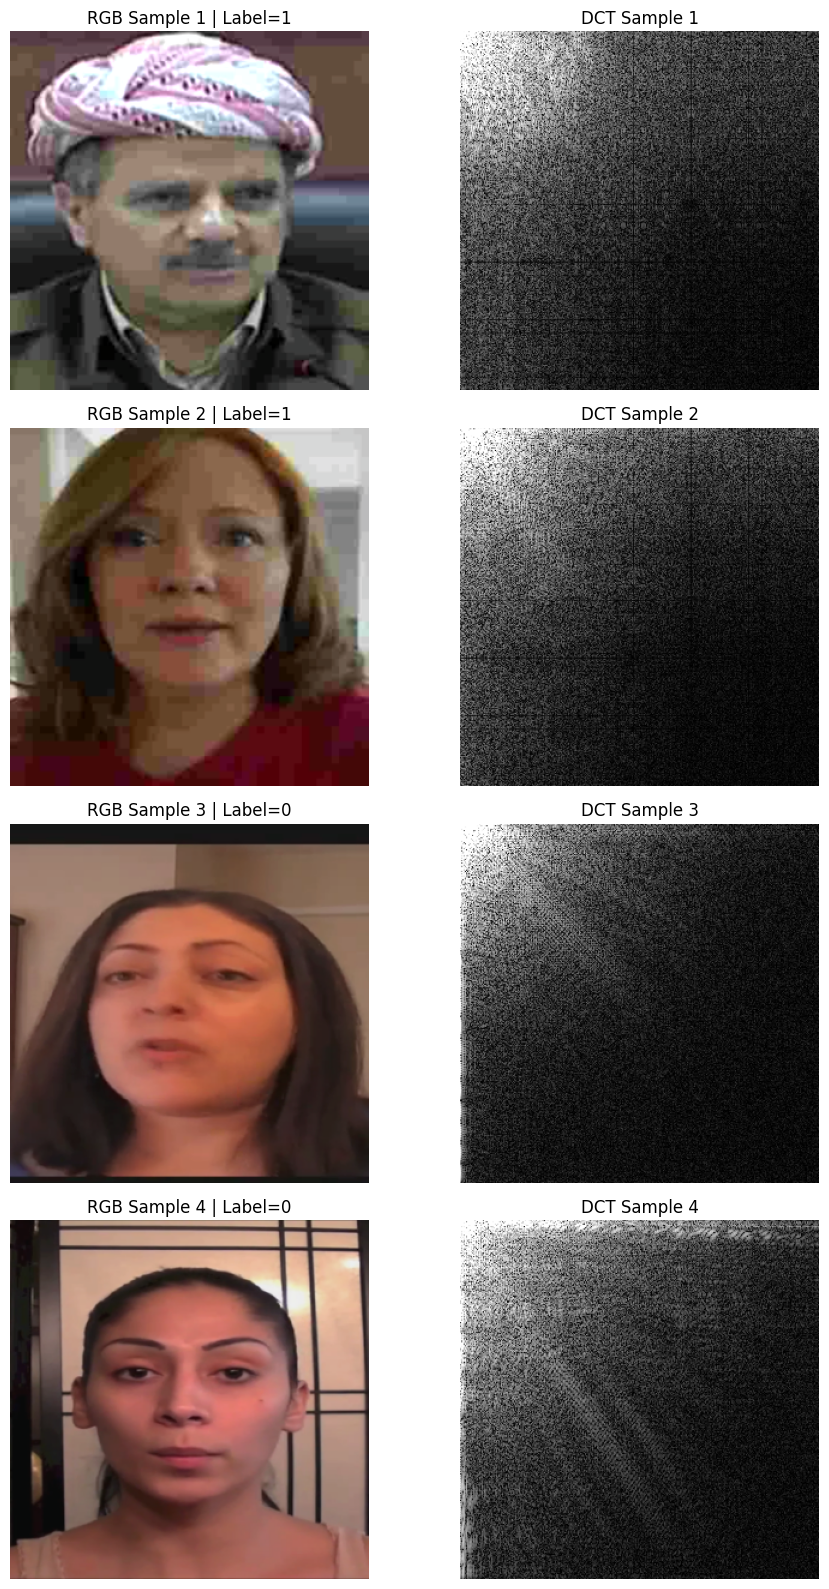

In [32]:
rgb_batch, dct_batch, labels = next(iter(train_loader))

num_samples = 4

plt.figure(figsize=(10, 4 * num_samples))

for i in range(num_samples):

    # rgb image..
    rgb_img = rgb_batch[i].permute(1, 2, 0).numpy()
    rgb_img = rgb_img * np.array(imagenet_std) + np.array(imagenet_mean)
    rgb_img = np.clip(rgb_img, 0, 1)

    plt.subplot(num_samples, 2, 2 * i + 1)
    plt.imshow(rgb_img)
    plt.title(f'RGB Sample {i+1} | Label={int(labels[i])}')
    plt.axis('off')

    # dct map,..
    plt.subplot(num_samples, 2, 2 * i + 2)
    plt.imshow(dct_batch[i].squeeze(0), cmap='gray')
    plt.title(f'DCT Sample {i+1}')
    plt.axis('off')

plt.tight_layout()
plt.show()

Frequency Branch...

In [33]:
class FrequencyBranch(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),

            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d(1)
        )

        self.fc = nn.Linear(128, 256)

    def forward(self, x):

        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        x = F.normalize(x, p=2, dim=1)

        return x

In [34]:
freq_branch = FrequencyBranch()
dummy_dct = torch.randn(4, 1, 299, 299)

output = freq_branch(dummy_dct)

print(output.shape)

torch.Size([4, 256])


DCTAwareXception...

In [35]:
class DCTCompressionAwareXception(nn.Module):

    def __init__(self):

        super().__init__()

        # rgp branch..

        self.rgb_backbone = timm.create_model('xception65', pretrained=True, num_classes=0)

        rgb_feature_dim = self.rgb_backbone.num_features

        # dct branch..

        self.freq_branch = FrequencyBranch()

        # fusion,..

        self.fusion = nn.Sequential(

            nn.Linear(rgb_feature_dim + 256, 512),

            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),

            nn.Linear(512, 1)
        )

    def forward(self, rgb, dct):

        rgb_features = self.rgb_backbone(rgb)
        rgb_features = F.normalize(rgb_features, p=2, dim=1)
        dct_features = self.freq_branch(dct)

        fused = torch.cat([rgb_features, dct_features], dim=1)
        logits = self.fusion(fused)

        return logits.squeeze(1)

In [36]:
model = DCTCompressionAwareXception()

model = model.to(device)

rgb = torch.randn(2,3, 299, 299).to(device)

dct = torch.randn(2,1,299, 299).to(device)

with torch.no_grad():
    output = model(rgb, dct)

print(output.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/160M [00:00<?, ?B/s]

torch.Size([2])


In [37]:
total_parameters = sum(p.numel() for p in model.parameters())

print(f'\nparameters: {total_parameters:,}')


parameters: 39,175,153


In [38]:
print(model.rgb_backbone.num_features)

2048


In [39]:
rgb = torch.randn(2,3,299,299).to(device)

with torch.no_grad():
    feat = model.rgb_backbone(rgb)

print(feat.shape)

torch.Size([2, 2048])


In [40]:
rgb_batch, dct_batch, labels = next(iter(train_loader))

rgb_batch = rgb_batch.to(device)
dct_batch = dct_batch.to(device)

with torch.no_grad():
    outputs = model(rgb_batch, dct_batch)

print(outputs.shape)
print(outputs[:5])

torch.Size([32])
tensor([0.2149, 0.5299, 1.0884, 0.1584, 0.4956], device='cuda:0')


Loss / Optimizer ...

In [41]:
criterion = torch.nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

In [42]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

AMP...

In [43]:
scaler = torch.amp.GradScaler('cuda')

Evaluation Function...

In [44]:
@torch.no_grad()

def evaluate(model, loader, criterion):

    model.eval()

    running_loss = 0.0

    all_labels = []
    all_probs = []
    all_preds = []

    for rgb_images, dct_images, labels in tqdm(loader, leave=False):

        rgb_images = rgb_images.to(device)
        dct_images = dct_images.to(device)

        labels = labels.to(device)
        outputs = model(rgb_images, dct_images)
        labels = labels.float().view_as(outputs)
        loss = criterion(outputs, labels)

        running_loss += (loss.item() * rgb_images.size(0))

        probs = torch.sigmoid(outputs)
        preds = (probs >= 0.5).float()

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

    epoch_loss = (running_loss / len(loader.dataset))
    auc = roc_auc_score(all_labels,all_probs)

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels,all_preds, zero_division=0)

    recall = recall_score(all_labels, all_preds, zero_division=0)

    f1 = f1_score(all_labels, all_preds, zero_division=0)

    return {
        'loss': epoch_loss,
        'auc': auc,

        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'labels': np.array(all_labels),
        'probs': np.array(all_probs),
        'preds': np.array(all_preds)
    }

In [45]:
val_metrics = evaluate(model, val_loader, criterion)
print(val_metrics.keys())

  0%|          | 0/75 [00:00<?, ?it/s]

dict_keys(['loss', 'auc', 'accuracy', 'precision', 'recall', 'f1', 'labels', 'probs', 'preds'])


Training Loop...

In [46]:
history = {
    'train_loss': [],
    'val_loss': [],
    'val_auc': [],

    'val_acc': [],
    'val_precision': [],
    'val_recall': [],
    'val_f1': []
}

best_auc = 0.0
patience_counter = 0

save_dir = '/content/drive/MyDrive/DL_Project/checkpoints'
os.makedirs(save_dir, exist_ok=True)
best_model_path = os.path.join(save_dir, 'best_cat_dct_xception.pth')

for epoch in range(maximum_epochs):

    print(f'\nEpoch [{epoch+1}/{maximum_epochs}]')

    # training..

    model.train()

    running_loss = 0.0

    pbar = tqdm(train_loader)

    for rgb_images, dct_images, labels in pbar:

        rgb_images = rgb_images.to(device, non_blocking=True)
        dct_images = dct_images.to(device,non_blocking=True)

        labels = labels.to(device, non_blocking=True).float()
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda'):

            outputs = model(rgb_images,dct_images)
            labels = labels.view_as(outputs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        scaler.step(optimizer)
        scaler.update()

        running_loss += (loss.item() * rgb_images.size(0))

        pbar.set_postfix(loss=f'{loss.item():.4f}')

    train_loss = (running_loss / len(train_loader.dataset))

    # validation...

    val_metrics = evaluate(model, val_loader, criterion)

    val_loss = val_metrics['loss']
    val_auc = val_metrics['auc']

    val_acc = val_metrics['accuracy']
    val_precision = val_metrics['precision']
    val_recall = val_metrics['recall']
    val_f1 = val_metrics['f1']

    scheduler.step(val_auc)

    # history..

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    history['val_auc'].append(val_auc)

    history['val_acc'].append(val_acc)
    history['val_precision'].append(val_precision)
    history['val_recall'].append(val_recall)
    history['val_f1'].append(val_f1)

    # logging..

    print(f'\nTrain Loss : {train_loss:.4f}')
    print(f'\nVal Loss   : {val_loss:.4f}')
    print(f'Val AUC    : {val_auc:.4f}')

    print(f'\nVal Accuracy  : {val_acc:.4f}')
    print(f'Val Precision : {val_precision:.4f}')
    print(f'Val Recall    : {val_recall:.4f}')
    print(f'Val F1        : {val_f1:.4f}')

    # saving best model...

    if val_auc > best_auc:
        best_auc = val_auc

        patience_counter = 0

        torch.save({

            'epoch': epoch + 1,

            'model_state_dict':
                model.state_dict(),

            'optimizer_state_dict':
                optimizer.state_dict(),

            'best_auc':
                best_auc

        }, best_model_path)

        print(
            f'\nBest model saved '
            f'(AUC={best_auc:.4f})'
        )

    else:
        patience_counter += 1

        print(
            f'\nNo improvement '
            f'({patience_counter}/{patience})'
        )

    # early stopping,..

    if patience_counter >= patience:
        print('\nEarly stopping triggered...')

        break

history_df = pd.DataFrame(history)

results_dir = ('/content/drive/MyDrive/DL_Project/results/dct_cat_xception')
os.makedirs(results_dir, exist_ok=True)
history_df.to_csv(os.path.join(results_dir, 'dct_cat_xception_training_history.csv'), index=False)
print('training history saved...')


Epoch [1/20]


  0%|          | 0/449 [00:00<?, ?it/s]

  0%|          | 0/75 [00:00<?, ?it/s]


Train Loss : 0.5471

Val Loss   : 0.4445
Val AUC    : 0.8965

Val Accuracy  : 0.8139
Val Precision : 0.8459
Val Recall    : 0.7434
Val F1        : 0.7913

Best model saved (AUC=0.8965)

Epoch [2/20]


  0%|          | 0/449 [00:00<?, ?it/s]

...

  0%|          | 0/75 [00:00<?, ?it/s]


Train Loss : 0.0496

Val Loss   : 0.4745
Val AUC    : 0.9587

Val Accuracy  : 0.8966
Val Precision : 0.8611
Val Recall    : 0.9327
Val F1        : 0.8955

No improvement (4/5)

Epoch [14/20]


  0%|          | 0/449 [00:00<?, ?it/s]

  0%|          | 0/75 [00:00<?, ?it/s]


Train Loss : 0.0477

Val Loss   : 0.5070
Val AUC    : 0.9558

Val Accuracy  : 0.8920
Val Precision : 0.8766
Val Recall    : 0.8991
Val F1        : 0.8877

No improvement (5/5)

Early stopping triggered...
training history saved...


Load Model Checkpoint...

In [47]:
checkpoint_path = ('/content/drive/MyDrive/DL_Project/checkpoints/best_cat_dct_xception.pth')
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

model.load_state_dict(checkpoint['model_state_dict'])

model.eval()

print(f'best epoch : {checkpoint['epoch']}')
print(f'best auc   : {checkpoint['best_auc']:.4f}')

best epoch : 9
best auc   : 0.9673


In [48]:
print(len(test_loader.dataset))
print(len(celeb_loader.dataset))

2388
5990


Learning Curves...

In [49]:
history_df = pd.read_csv('/content/drive/MyDrive/DL_Project/results/dct_cat_xception/dct_cat_xception_training_history.csv')

In [50]:
history_df['epoch'] = range(1,len(history_df) + 1)
history_df.head()

,train_loss,val_loss,val_auc,val_acc,val_precision,val_recall,val_f1,epoch
0,0.547119,0.444450,0.896452,0.813866,0.845921,0.743363,0.791333,1
1,0.279369,0.426635,0.935034,0.836134,0.773264,0.926549,0.842995,2
2,0.189257,0.371372,0.948073,0.864286,0.827251,0.902655,0.863309,3
3,0.161024,0.371188,0.954317,0.871429,0.833333,0.911504,0.870668,4
4,0.124866,0.478586,0.947237,0.857983,0.809859,0.915929,0.859635,5


In [51]:
output_dir = '/content/drive/MyDrive/DL_Project/results/dct_cat_xception/'
os.makedirs(output_dir, exist_ok=True)

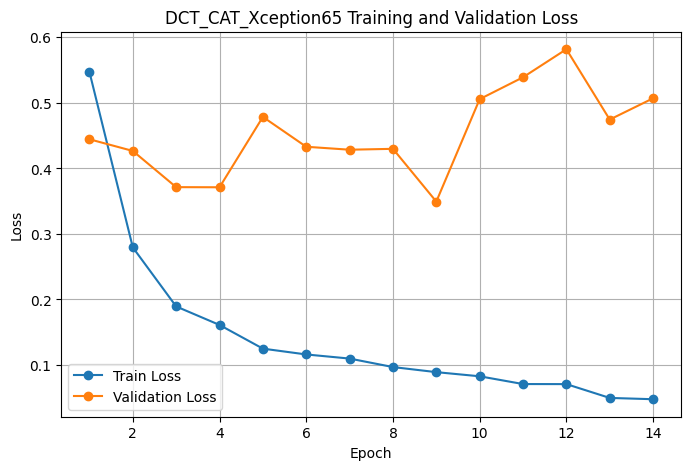

In [52]:
plt.figure(figsize=(8,5))

plt.plot(history_df['epoch'], history_df['train_loss'], marker='o', label='Train Loss')

plt.plot(history_df['epoch'], history_df['val_loss'], marker='o', label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('DCT_CAT_Xception65 Training and Validation Loss')

plt.legend()
plt.grid(True)

save_path = os.path.join(output_dir, 'dct_cat_xception65_loss_plot.pdf')
plt.savefig(save_path, bbox_inches='tight')

plt.show()

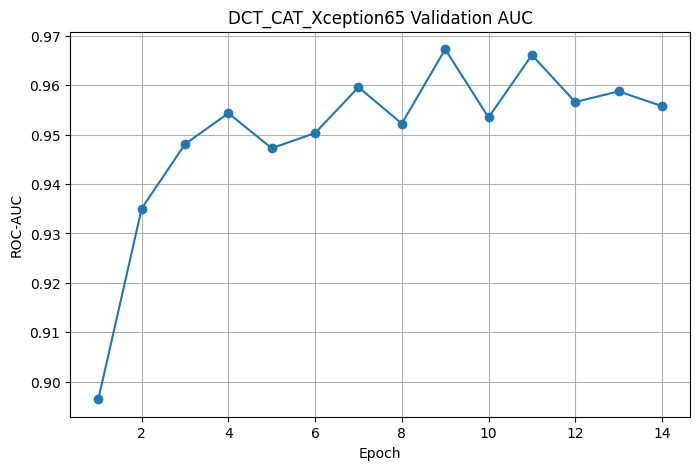

In [53]:
plt.figure(figsize=(8,5))

plt.plot(history_df['epoch'], history_df['val_auc'], marker='o')

plt.xlabel('Epoch')
plt.ylabel('ROC-AUC')
plt.title('DCT_CAT_Xception65 Validation AUC')

plt.grid(True)

save_path = os.path.join(output_dir, 'dct_cat_xception65_auc_curve.pdf')
plt.savefig(save_path, bbox_inches='tight')

plt.show()

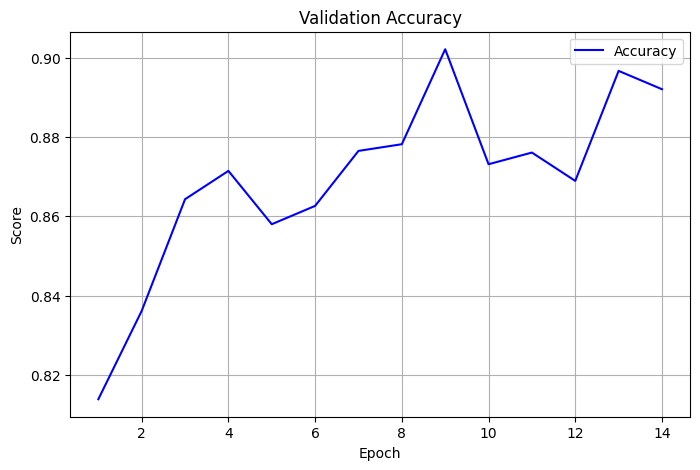

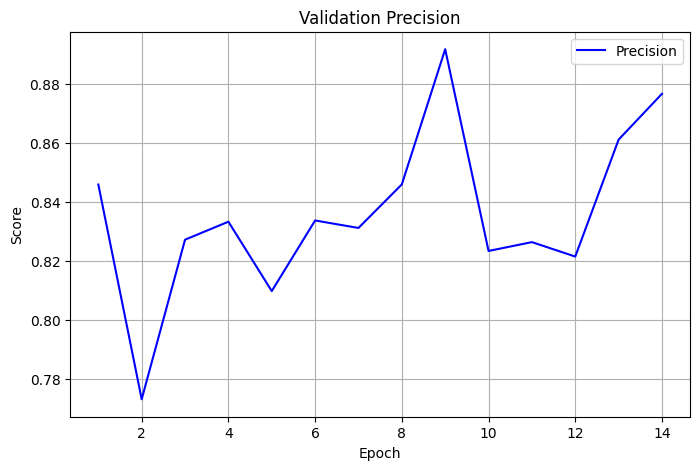

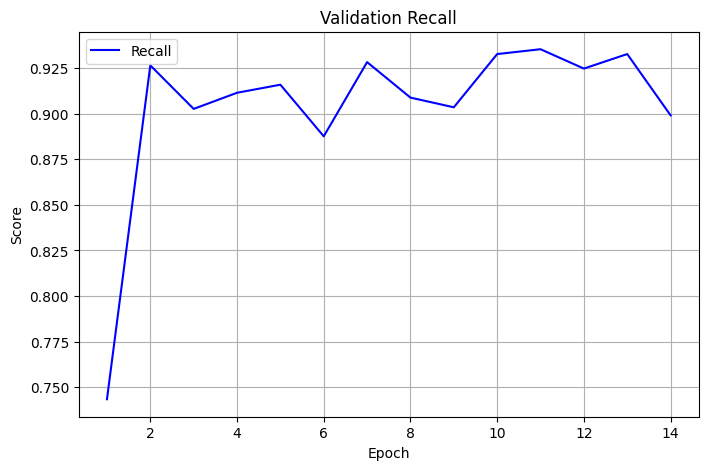

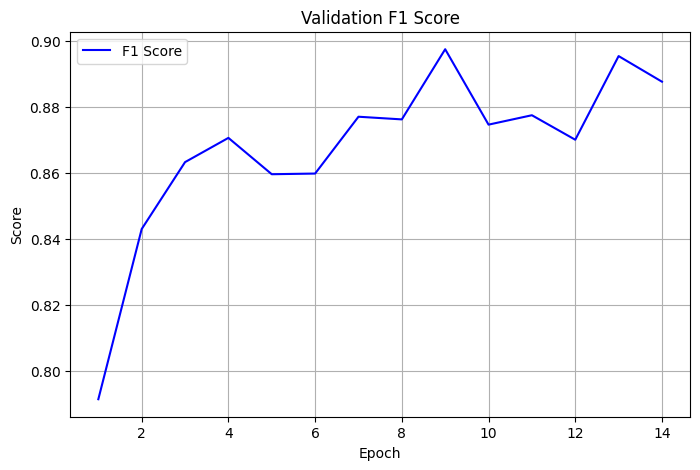

In [54]:
metrics = ['val_acc', 'val_precision', 'val_recall', 'val_f1']
display_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

for metric, name in zip(metrics, display_names):
    plt.figure(figsize=(8,5))

    plt.plot(history_df['epoch'], history_df[metric], label=name, color='blue')

    plt.xlabel('Epoch')
    plt.ylabel('Score')
    plt.title(f'Validation {name}')

    plt.legend()
    plt.grid(True)

    file_name = f'dct_cat_xception65_{metric}.pdf'
    save_path = os.path.join(output_dir, file_name)
    plt.savefig(save_path, bbox_inches='tight')

    plt.show()

FF++ Evaluation...

In [55]:
ffpp_metrics = evaluate(model, test_loader, criterion)

print('\nfaceforensics++ test results')

print(f'AUC  : {ffpp_metrics['auc']:.4f}')
print(f'Accuracy  : {ffpp_metrics['accuracy']:.4f}')
print(f'Precision  : {ffpp_metrics['precision']:.4f}')
print(f'Recall  : {ffpp_metrics['recall']:.4f}')
print(f'F1  : {ffpp_metrics['f1']:.4f}')

  0%|          | 0/75 [00:00<?, ?it/s]


faceforensics++ test results
AUC  : 0.9388
Accuracy  : 0.8769
Precision  : 0.8644
Recall  : 0.8796
F1  : 0.8720


FF++ ROC Curve...

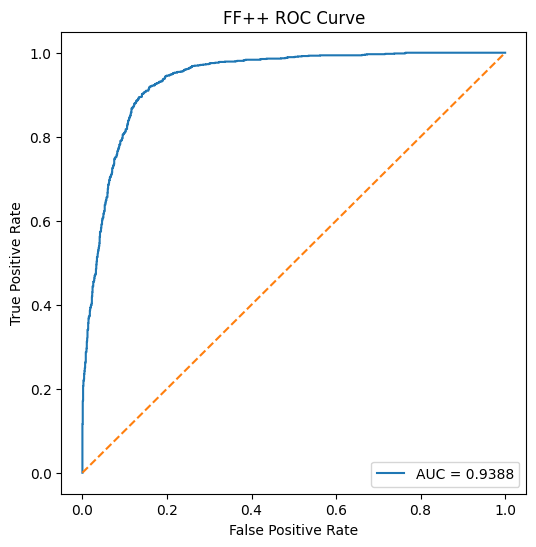

In [56]:
fpr, tpr, _ = roc_curve(ffpp_metrics['labels'], ffpp_metrics['probs'])

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label=f'AUC = {ffpp_metrics['auc']:.4f}')

plt.plot([0,1], [0,1], '--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('FF++ ROC Curve')

plt.legend()

save_path = os.path.join(output_dir, 'dct_cat_xception65_ffpp_roc_curve.pdf')
plt.savefig(save_path, bbox_inches='tight')

plt.show()

FF++ Confusion Matrix...

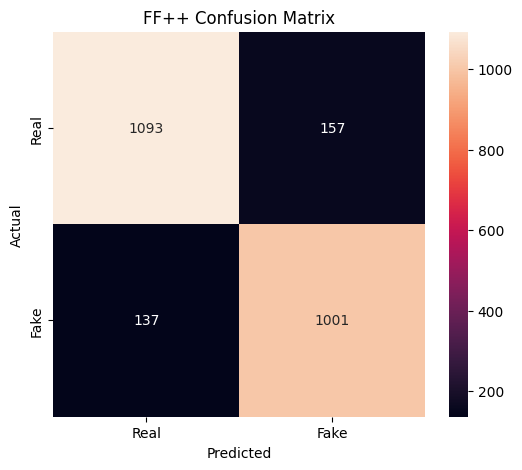

In [57]:
import seaborn as sns

cm = confusion_matrix(ffpp_metrics['labels'], ffpp_metrics['preds'])

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Real','Fake'],
    yticklabels=['Real','Fake']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.title('FF++ Confusion Matrix')

save_path = os.path.join(output_dir, 'dct_cat_xception65_ffpp_confusion_matrix.pdf')
plt.savefig(save_path, bbox_inches='tight')

plt.show()

CelebV2 Evaluation...

In [58]:
celeb_metrics = evaluate(model, celeb_loader, criterion)

print('\ncelebv2 evaluation results')

print(f'AUC  : {celeb_metrics['auc']:.4f}')
print(f'Accuracy  : {celeb_metrics['accuracy']:.4f}')
print(f'Precision  : {celeb_metrics['precision']:.4f}')
print(f'Recall  : {celeb_metrics['recall']:.4f}')
print(f'F1  : {celeb_metrics['f1']:.4f}')

  0%|          | 0/188 [00:00<?, ?it/s]


celebv2 evaluation results
AUC  : 0.7921
Accuracy  : 0.6344
Precision  : 0.5802
Recall  : 0.9689
F1  : 0.7258


CelebV2 ROC Curve...

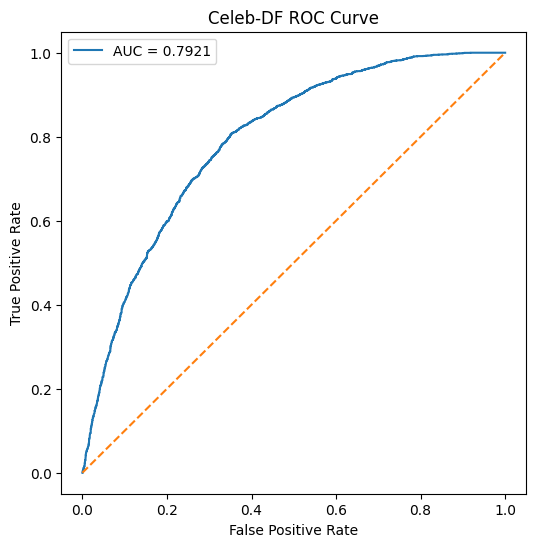

In [59]:
fpr, tpr, _ = roc_curve(celeb_metrics['labels'], celeb_metrics['probs'])

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label=f'AUC = {celeb_metrics['auc']:.4f}')

plt.plot([0,1], [0,1], '--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('Celeb-DF ROC Curve')

plt.legend()

save_path = os.path.join(output_dir, 'dct_cat_xception65_celebv2_roc_curve.pdf')
plt.savefig(save_path, bbox_inches='tight')

plt.show()

CelebV2 Confusion Matrix...

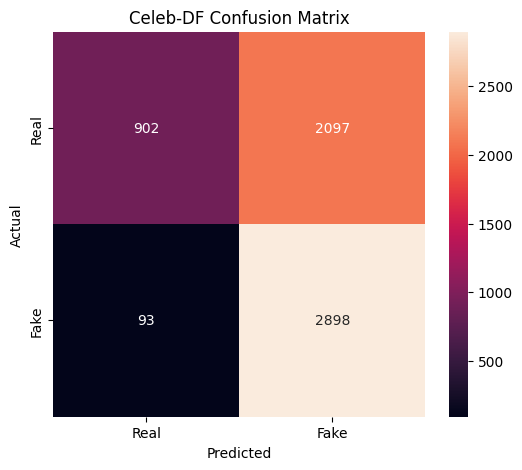

In [60]:
cm = confusion_matrix(celeb_metrics['labels'], celeb_metrics['preds'])

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Real','Fake'],
    yticklabels=['Real','Fake']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.title('Celeb-DF Confusion Matrix')

save_path = os.path.join(output_dir, 'dct_cat_xception65_celebv2_confusion_matrix.pdf')
plt.savefig(save_path, bbox_inches='tight')

plt.show()

Generalization Gap...

In [61]:
generalization_gap = (ffpp_metrics['auc'] - celeb_metrics['auc'])

print('\ngeneralization gap')

print(f'FF++ AUC  : {ffpp_metrics['auc']:.4f}')

print(f'CelebDF AUC  : {celeb_metrics['auc']:.4f}')

print(f'Gap  : {generalization_gap:.4f}')


generalization gap
FF++ AUC  : 0.9388
CelebDF AUC  : 0.7921
Gap  : 0.1466


Final Results Table...

In [62]:
results_df = pd.DataFrame([

    {
        'Dataset':'FF++ Test',

        'AUC':ffpp_metrics['auc'],
        'Accuracy':ffpp_metrics['accuracy'],
        'Precision':ffpp_metrics['precision'],
        'Recall':ffpp_metrics['recall'],
        'F1':ffpp_metrics['f1']
    },

    {
        'Dataset':'CelebDF',

        'AUC':celeb_metrics['auc'],
        'Accuracy':celeb_metrics['accuracy'],
        'Precision':celeb_metrics['precision'],
        'Recall':celeb_metrics['recall'],
        'F1':celeb_metrics['f1']
    }
])

results_df

,Dataset,AUC,Accuracy,Precision,Recall,F1
0,FF++ Test,0.938794,0.876884,0.864421,0.879613,0.871951
1,CelebDF,0.792147,0.634391,0.580180,0.968907,0.725770


In [63]:
results_dir = '/content/drive/MyDrive/DL_Project/results/dct_cat_xception/'

os.makedirs(results_dir, exist_ok=True)

results_df.to_csv(os.path.join(results_dir, 'dct_cat_xception65_results.csv'), index=False)

print('results saved.')

results saved.
